# BLIP (Bootstrapping Language-Image Pre-training) 사용 예제

Salesforce의 BLIP은 이미지와 텍스트를 이해하는 멀티태스크 비전-언어 모델입니다.
CLIP과 달리 **임베딩 유사도**뿐 아니라 **자연어 생성**을 통해 이미지를 설명하거나 질문에 답할 수 있습니다.

논문: https://arxiv.org/abs/2201.12086

이 노트북에서 다루는 내용:
1. BLIP 모델 로드 (Captioning / VQA / ITM)
2. **이미지 캡셔닝** — 이미지를 자연어로 설명
3. **조건부 캡셔닝** — 텍스트 프리픽스로 생성 유도
4. **Beam Search** — 여러 캡션 후보 생성
5. **Visual Question Answering (VQA)** — 이미지에 대한 질문 답변
6. **Image-Text Matching (ITM)** — 이미지-텍스트 쌍 일치 여부 판별
7. **배치 캡셔닝** — 여러 이미지 한꺼번에 설명
8. **텍스트 쿼리로 가장 잘 맞는 이미지 찾기** (ITM 기반)

## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

```
torch>=2.0.0
torchvision>=0.15.0
transformers>=4.40.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
jupyter>=1.0.0
ipykernel>=6.29.0
```
BLIP 모델 3종(캡셔닝·VQA·ITM)을 사용하므로 최초 실행 시 Hugging Face Hub에서 약 3GB를 다운로드합니다.

In [1]:
# Jupyter 위젯 사용 시 필요 (이 노트북에서는 선택 사항)
# %pip install ipywidgets

In [1]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import (
    BlipProcessor,                      # BLIP 전처리기 (이미지·텍스트 → 텐서)
    BlipForConditionalGeneration,         # 캡셔닝·VQA용 생성 모델
    BlipForQuestionAnswering,
    BlipForImageTextRetrieval,            # ITM: 이미지-텍스트 매칭 점수
)


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


setup_korean_font()

# GPU 사용 가능 시 cuda, 아니면 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")

사용 디바이스: cuda
matplotlib 폰트: ['Malgun Gothic']


## 2. BLIP 모델 로드

BLIP은 태스크별로 전용 헤드가 있는 모델을 사용합니다.

| 모델 | 용도 |
|------|------|
| `Salesforce/blip-image-captioning-base` | 이미지 → 텍스트 캡션 생성 |
| `Salesforce/blip-vqa-base` | 이미지 + 질문 → 답변 생성 |
| `Salesforce/blip-itm-base-coco` | 이미지-텍스트 쌍 일치 점수 |

더 높은 품질이 필요하면 `-large` 변형을 사용할 수 있습니다.

In [3]:
CAPTION_MODEL = "Salesforce/blip-image-captioning-base"   # 이미지 → 텍스트 캡션
VQA_MODEL = "Salesforce/blip-vqa-base"                    # 이미지 + 질문 → 답변
ITM_MODEL = "Salesforce/blip-itm-base-coco"               # 이미지-텍스트 일치 점수

# --- Captioning ---
# Hugging Face Hub에서 모델·전처리기 로드 (최초 실행 시 캐시에 다운로드)
caption_processor = BlipProcessor.from_pretrained(CAPTION_MODEL)
caption_model = BlipForConditionalGeneration.from_pretrained(CAPTION_MODEL).to(device)
caption_model.eval()  # 추론 모드: dropout 등 비활성화
print(f"캡셔닝 모델 로드 완료: {CAPTION_MODEL}")

# --- VQA ---
vqa_processor = BlipProcessor.from_pretrained(VQA_MODEL)
vqa_model = BlipForQuestionAnswering.from_pretrained(VQA_MODEL).to(device)
vqa_model.eval()
print(f"VQA 모델 로드 완료: {VQA_MODEL}")

# --- ITM (Image-Text Matching) ---
itm_processor = BlipProcessor.from_pretrained(ITM_MODEL)
itm_model = BlipForImageTextRetrieval.from_pretrained(ITM_MODEL).to(device)
itm_model.eval()
print(f"ITM 모델 로드 완료: {ITM_MODEL}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

캡셔닝 모델 로드 완료: Salesforce/blip-image-captioning-base


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

VQA 모델 로드 완료: Salesforce/blip-vqa-base


Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

ITM 모델 로드 완료: Salesforce/blip-itm-base-coco


## 3. 샘플 이미지 준비

[MS COCO](https://cocodataset.org/) val2017에서 **예제에 사용할 몇 장만** URL로 불러옵니다.
전체 데이터셋(~1GB)을 다운로드하지 않고, COCO 공식 CDN에서 필요한 이미지만 가져옵니다.

- 이미지 URL: `http://images.cocodataset.org/val2017/{file_name}`
- 고해상도 실사(640×480 전후) — CIFAR-10(32×32)보다 BLIP 데모에 적합
- 각 샘플에 COCO **참고 캡션** 포함 (BLIP 생성 결과와 비교용)

로컬 이미지를 쓰려면 `Image.open("경로/이미지.jpg")` 또는 `load_image_from_url("https://...")`를 사용하면 됩니다.

URL: http://images.cocodataset.org/val2017/000000543581.jpg
COCO image_id=543581, category=dog, size=(640, 427)
COCO 참고 캡션: A dog is sitting on the couch in a living room.


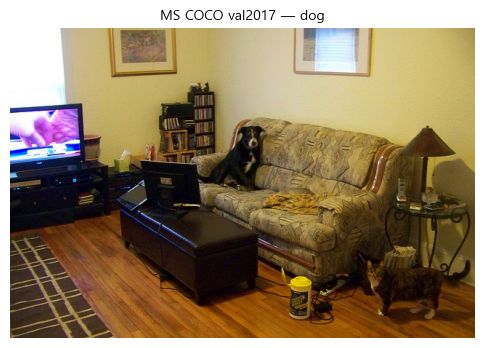

In [4]:
from dataclasses import dataclass

# COCO 공식 CDN — val2017 이미지를 개별 URL로 제공
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# MS COCO val2017 — 예제용 샘플만 URL로 지정 (전체 데이터셋 다운로드 불필요)
# file_name: COCO val2017 파일명, captions: 사람이 작성한 참고 캡션 (BLIP 결과 비교용)
COCO_SAMPLE_URLS: dict[str, dict] = {
    "dog": {
        "file_name": "000000543581.jpg",
        "image_id": 543581,
        "captions": [
            "A dog is sitting on the couch in a living room.",
            "A cute black dog sitting on the couch.",
        ],
    },
    "cat": {
        "file_name": "000000039769.jpg",
        "image_id": 39769,
        "captions": [
            "There are two cats laying down with two remotes",
            "Two cats sleeping with a remote control near each of them.",
        ],
    },
    "car": {
        "file_name": "000000527220.jpg",
        "image_id": 527220,
        "captions": [
            "A red car next to a gas station sign and parked blue and silver motorcycles.",
            "A red Ferrari at a gas station showing the gas prices and three mopeds",
        ],
    },
    "airplane": {
        "file_name": "000000001761.jpg",
        "image_id": 1761,
        "captions": [
            "Two planes flying in the sky over a bridge.",
            "Two planes fly over a bridge in Sydney, Australia, with the Sydney Opera House in the background.",
        ],
    },
}

COCO_SAMPLE_CATEGORIES = list(COCO_SAMPLE_URLS.keys())
_url_image_cache: dict[str, Image.Image] = {}  # 동일 URL 재요청 방지


@dataclass
class CocoSample:
    """COCO URL 샘플 1건 — 이미지 + 메타데이터"""
    image: Image.Image
    image_id: int
    category: str
    url: str
    captions: list[str]


def load_image_from_url(url: str) -> Image.Image:
    """URL에서 이미지 로드 (캐시 + User-Agent)"""
    if url in _url_image_cache:
        return _url_image_cache[url].copy()

    headers = {"User-Agent": "BLIP-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def load_coco_sample_meta(category: str) -> CocoSample:
    """COCO val2017 URL에서 샘플 이미지 + 참고 캡션 반환"""
    if category not in COCO_SAMPLE_URLS:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_SAMPLE_CATEGORIES)}"
        )
    meta = COCO_SAMPLE_URLS[category]
    url = COCO_IMAGE_BASE + meta["file_name"]
    image = load_image_from_url(url)
    return CocoSample(
        image=image,
        image_id=meta["image_id"],
        category=category,
        url=url,
        captions=meta["captions"],
    )


def load_coco_sample(category: str) -> Image.Image:
    """지정 COCO 카테고리 샘플 이미지만 반환"""
    return load_coco_sample_meta(category).image


def load_coco_samples(categories: list[str]) -> list[CocoSample]:
    """여러 카테고리 샘플을 한꺼번에 로드"""
    return [load_coco_sample_meta(cat) for cat in categories]


def show_image(image: Image.Image, title: str = ""):
    """이미지 1장 표시 (고해상도 COCO용 figsize=6)"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=10)
    plt.show()


# 예제용 강아지 이미지 로드 — 이후 섹션에서 `image`, `sample` 변수 재사용
sample = load_coco_sample_meta("dog")
image = sample.image
print(f"URL: {sample.url}")
print(f"COCO image_id={sample.image_id}, category={sample.category}, size={image.size}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, f"MS COCO val2017 — {sample.category}")

## 4. 이미지 캡셔닝

BLIP은 이미지를 보고 자연어 설명(캡션)을 생성합니다.
CLIP처럼 미리 정의된 클래스 중 선택하는 것이 아니라, **자유 형식 텍스트**를 출력합니다.

BLIP 생성 캡션: a dog sitting on a couch in a living room
COCO 참고 캡션: A dog is sitting on the couch in a living room.


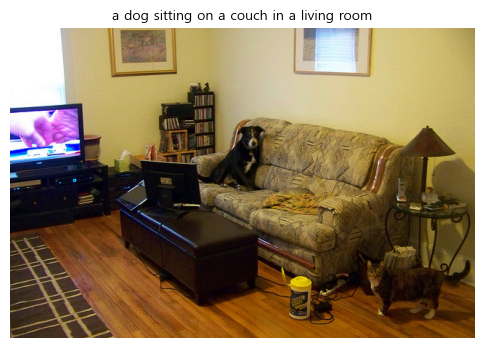

In [5]:
def generate_caption(img: Image.Image, prompt: str | None = None, **generate_kwargs) -> str:
    """이미지 → 캡션 생성. prompt가 있으면 조건부 생성(프리픽스)."""
    if prompt:
        # 조건부: prompt를 디코더 입력 앞에 붙여 생성 방향 유도
        inputs = caption_processor(images=img, text=prompt, return_tensors="pt")
    else:
        # 무조건부: 이미지만으로 캡션 생성
        inputs = caption_processor(images=img, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = caption_model.generate(**inputs, max_new_tokens=40, **generate_kwargs)
    return caption_processor.decode(output_ids[0], skip_special_tokens=True)


caption = generate_caption(image)
print(f"BLIP 생성 캡션: {caption}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, caption)

## 5. 조건부 캡셔닝

텍스트 프리픽스를 주면 해당 방향으로 캡션 생성을 유도할 수 있습니다.
예: `"a photo of"` → `"a photo of a dog sitting on grass"`

In [6]:
# 텍스트 프리픽스를 바꿔가며 캡션 생성 방향 비교
prefixes = ["a photo of", "this image shows", "there is"]

for prefix in prefixes:
    cap = generate_caption(image, prompt=prefix)
    print(f"  [{prefix}] → {cap}")

  [a photo of] → a photo of a living room with a dog on the couch
  [this image shows] → this image shows a living room with a couch and a television
  [there is] → there is a dog sitting on a couch


## 6. Beam Search — 여러 캡션 후보

Beam Search로 여러 후보 캡션을 생성하고, 가장 자연스러운 설명을 선택할 수 있습니다.

In [7]:
inputs = caption_processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    output_ids = caption_model.generate(
        **inputs,
        max_new_tokens=40,
        num_beams=5,              # beam width — 클수록 다양한 후보 탐색
        num_return_sequences=3,   # 상위 3개 시퀀스 반환
    )

print("Beam Search 캡션 후보:")
for i, ids in enumerate(output_ids, start=1):
    cap = caption_processor.decode(ids, skip_special_tokens=True)
    print(f"  {i}. {cap}")

Beam Search 캡션 후보:
  1. a dog sitting on a couch in a living room
  2. a dog is sitting on a couch in a living room
  3. a dog sitting on a couch in front of a television


## 7. Visual Question Answering (VQA)

이미지와 자연어 질문을 입력하면 BLIP이 답변을 생성합니다.
질문은 영어로 작성하는 것이 좋습니다.

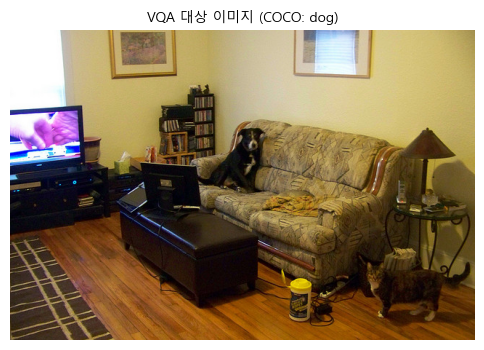

VQA 결과:
  Q: what animal is in this photo?
  A: dog

  Q: where is the dog sitting?
  A: couch

  Q: is the dog indoors or outdoors?
  A: indoors



In [8]:
def answer_question(img: Image.Image, question: str) -> str:
    """이미지 + 질문 → 답변 생성 (VQA)"""
    inputs = vqa_processor(images=img, text=question, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = vqa_model.generate(**inputs, max_new_tokens=20)
    return vqa_processor.decode(output_ids[0], skip_special_tokens=True)


# BLIP VQA는 영어 질문에 최적화
questions = [
    "what animal is in this photo?",
    "where is the dog sitting?",
    "is the dog indoors or outdoors?",
]

show_image(image, f"VQA 대상 이미지 (COCO: {sample.category})")
print("VQA 결과:")
for q in questions:
    ans = answer_question(image, q)
    print(f"  Q: {q}")
    print(f"  A: {ans}\n")

## 8. Image-Text Matching (ITM)

ITM 모델은 이미지와 텍스트 설명이 **얼마나 잘 맞는지** 점수로 판별합니다.
CLIP의 zero-shot 분류와 유사하지만, BLIP은 교차 어텐션 기반 매칭 헤드를 사용합니다.

In [9]:
def compute_itm_scores(img: Image.Image, texts: list[str]) -> torch.Tensor:
    """이미지 1장 vs 텍스트 N개 → 각 텍스트의 매칭 확률 [N]"""
    # ITM은 이미지·텍스트 쌍마다 교차 어텐션으로 match/no-match 분류
    inputs = itm_processor(
        images=[img] * len(texts),  # 동일 이미지를 텍스트 수만큼 복제
        text=texts,
        return_tensors="pt",
        padding=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = itm_model(**inputs)
    # itm_score: [N, 2] → softmax 후 'match' 클래스(index=1) 확률
    return torch.softmax(outputs.itm_score, dim=-1)[:, 1]


# zero-shot 분류와 유사 — 후보 텍스트 중 가장 높은 match 확률 선택
candidate_texts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of an airplane",
]

itm_probs = compute_itm_scores(image, candidate_texts)

print("ITM 매칭 확률:")
for text, prob in sorted(zip(candidate_texts, itm_probs.cpu().tolist()), key=lambda x: x[1], reverse=True):
    print(f"  {prob:6.2%}  {text}")

ITM 매칭 확률:
   1.40%  a photo of a dog
   0.41%  a photo of a cat
   0.36%  a photo of a car
   0.02%  a photo of an airplane


## 9. 배치 캡셔닝

COCO URL 샘플 4종(dog, cat, car, airplane)을 불러와 캡션을 한꺼번에 생성합니다.
BLIP 생성 캡션과 COCO 참고 캡션을 비교해 볼 수 있습니다.

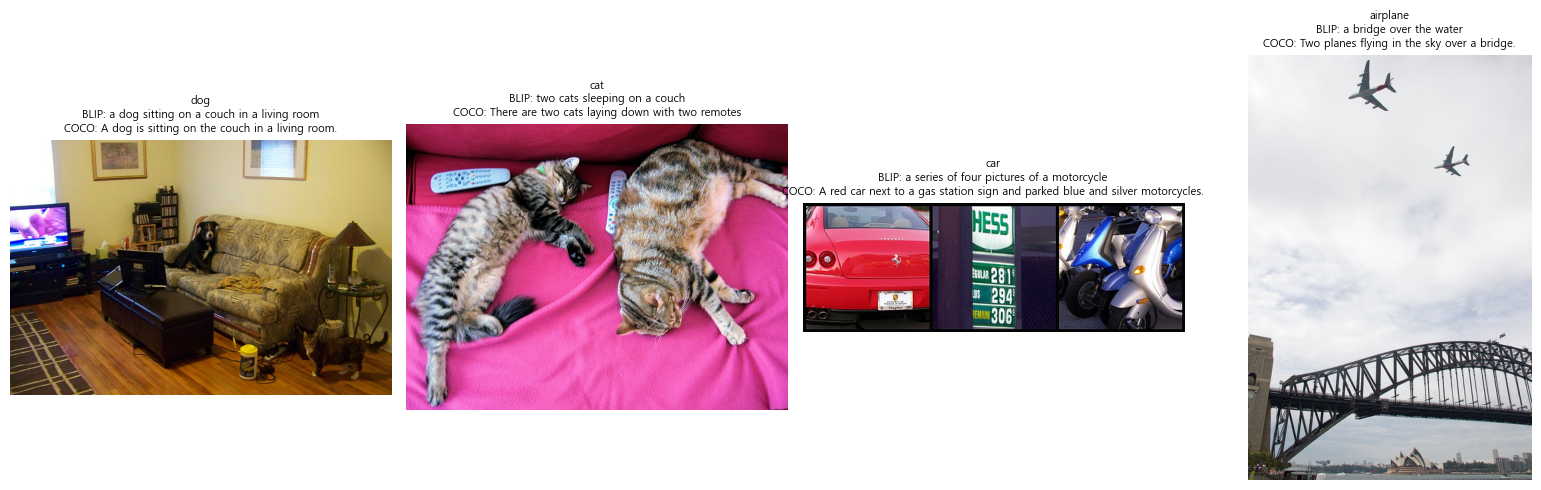

In [10]:
# COCO URL 샘플 4종을 불러와 각각 캡션 생성
batch_samples = load_coco_samples(["dog", "cat", "car", "airplane"])

fig, axes = plt.subplots(1, len(batch_samples), figsize=(16, 5))
for ax, coco_sample in zip(axes, batch_samples):
    cap = generate_caption(coco_sample.image)
    gt = coco_sample.captions[0]  # COCO 사람 작성 참고 캡션
    ax.imshow(coco_sample.image)
    ax.axis("off")
    ax.set_title(
        f"{coco_sample.category}\nBLIP: {cap}\nCOCO: {gt}",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

## 10. 텍스트 쿼리로 가장 잘 맞는 이미지 찾기

여러 이미지 후보 중 ITM 점수가 가장 높은 이미지를 선택합니다.
CLIP 임베딩 검색과 유사한 패턴이지만, BLIP ITM은 교차 어텐션 기반 매칭을 사용합니다.

쿼리: 'a cute pet animal'
가장 유사한 이미지: cat (ITM score=0.0376)


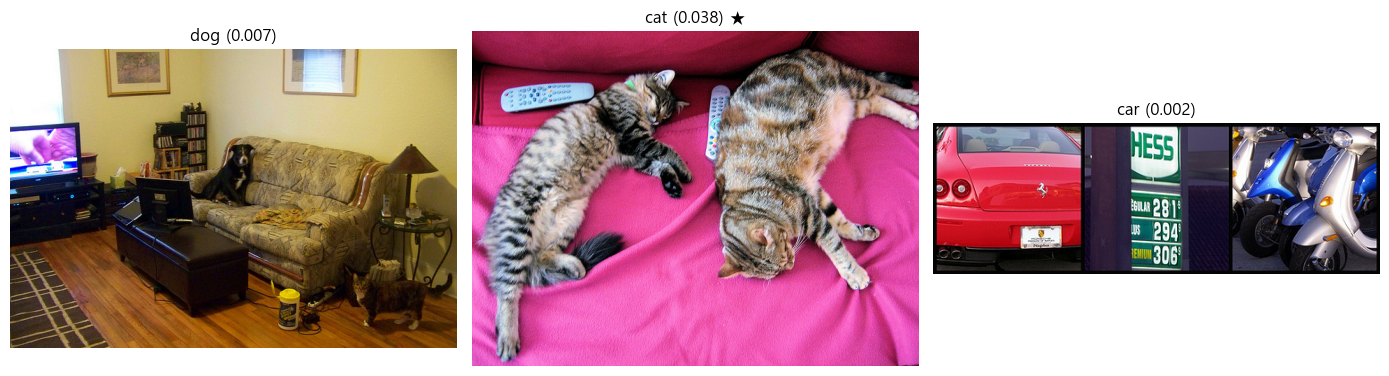

In [11]:
# 후보 이미지 3장 — ITM으로 텍스트 쿼리와 가장 잘 맞는 이미지 선택
candidate_samples = load_coco_samples(["dog", "cat", "car"])
candidate_images = [s.image for s in candidate_samples]
candidate_labels = [s.category for s in candidate_samples]

query = "a cute pet animal"

scores = []
for img in candidate_images:
    prob = compute_itm_scores(img, [query]).item()
    scores.append(prob)

best_idx = max(range(len(scores)), key=lambda i: scores[i])
print(f"쿼리: '{query}'")
print(f"가장 유사한 이미지: {candidate_labels[best_idx]} (ITM score={scores[best_idx]:.4f})")

fig, axes = plt.subplots(1, len(candidate_images), figsize=(14, 5))
for ax, img, score, idx, label in zip(
    axes, candidate_images, scores, range(len(candidate_images)), candidate_labels
):
    ax.imshow(img)
    ax.axis("off")
    marker = " ★" if idx == best_idx else ""  # 최고 점수 표시
    ax.set_title(f"{label} ({score:.3f}){marker}")
plt.tight_layout()
plt.show()

## 11. CLIP vs BLIP 비교 요약

| | CLIP | BLIP |
|---|---|---|
| **핵심 방식** | 대조 학습 임베딩 | 생성 + 매칭 + VQA |
| **주요 출력** | 유사도 점수 / 임베딩 벡터 | 자연어 텍스트 / 매칭 점수 |
| **Zero-shot 분류** | 텍스트 프롬프트와 유사도 비교 | ITM 매칭 또는 VQA |
| **이미지 설명** | ✗ (직접 생성 불가) | ✓ 캡셔닝 |
| **질문 답변** | ✗ | ✓ VQA |
| **검색** | 임베딩 코사인 유사도 | ITM 매칭 점수 또는 ITC 임베딩 |

실무에서는 **CLIP**은 대규모 이미지 검색·분류, **BLIP**은 캡션 생성·VQA·세밀한 이미지-텍스트 이해에 주로 사용된다.<br>
LIP(BLIP)는 기본적으로 영어 중심으로 학습된 모델이므로 한글 사용 가능 여부는 버전에 따라 다르다.<br>
최신 버전인 **BLIP-2**는 frozen vision encoder + Q-Former로 더 효율적이며, LLM과 결합해 고품질 캡션·대화가 가능하다.<br>
BLIP-2는 비전 인코더와 LLM을 연결하는 구조이다. 연결된 LLM이 다국어를 지원하면 한글 질문도 가능하다